***INTEGRANTES: Thiago Furriel de Castro e Vítor Vargas dos Santos***

**RK4**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def rk4_sistema(f, ti, tf, N, r0):
    h = (tf - ti) / N
    tp = np.arange(ti, tf + h, h)

    r = np.array(r0, dtype=float)
    rp = []

    for t in tp:
        rp.append(r.copy())

        k1 = h * f(r, t)
        k2 = h * f(r + 0.5 * k1, t + 0.5 * h)
        k3 = h * f(r + 0.5 * k2, t + 0.5 * h)
        k4 = h * f(r + k3, t + h)

        r += (1/6) * (k1 + 2*k2 + 2*k3 + k4)

    return tp, np.array(rp).T

**SIR Clássico**

In [ ]:
N_pop = 100000
I0 = 2
R0_rec = 0
S0 = N_pop - I0 - R0_rec

gamma = 0.2
R_zero = 2.5
beta = (R_zero * gamma) / S0

condicao_inicial = [S0, I0, R0_rec]

def equacoes_SIR(r, t):
    S, I, R = r

    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I

    return np.array([dSdt, dIdt, dRdt])

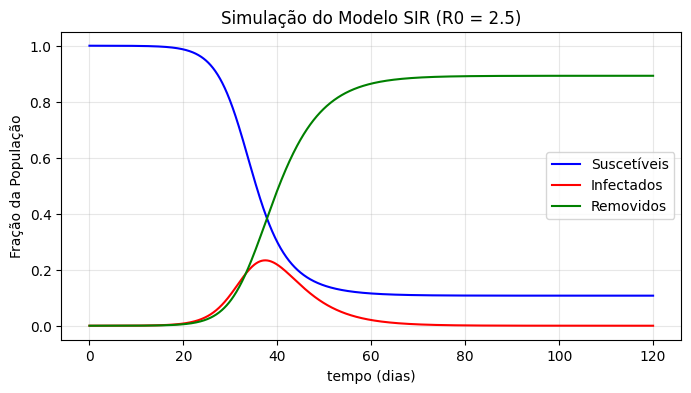

In [ ]:
ti = 0
tf = 120
h = 0.1
N_passos = int((tf - ti) / h)

tempo, resultados = rk4_sistema(equacoes_SIR, ti, tf, N_passos, condicao_inicial)

S_classic = resultados[0]
I_classic = resultados[1]
R_classic = resultados[2]

plt.figure(figsize=(8, 4))
plt.plot(tempo, S_classic / N_pop, 'b-', label='Suscetíveis')
plt.plot(tempo, I_classic / N_pop, 'r-', label='Infectados')
plt.plot(tempo, R_classic / N_pop, 'g-', label='Removidos')
plt.xlabel('tempo (dias)')
plt.ylabel('Fração da População')
plt.title(f'Simulação do Modelo SIR (R0 = {R_zero})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

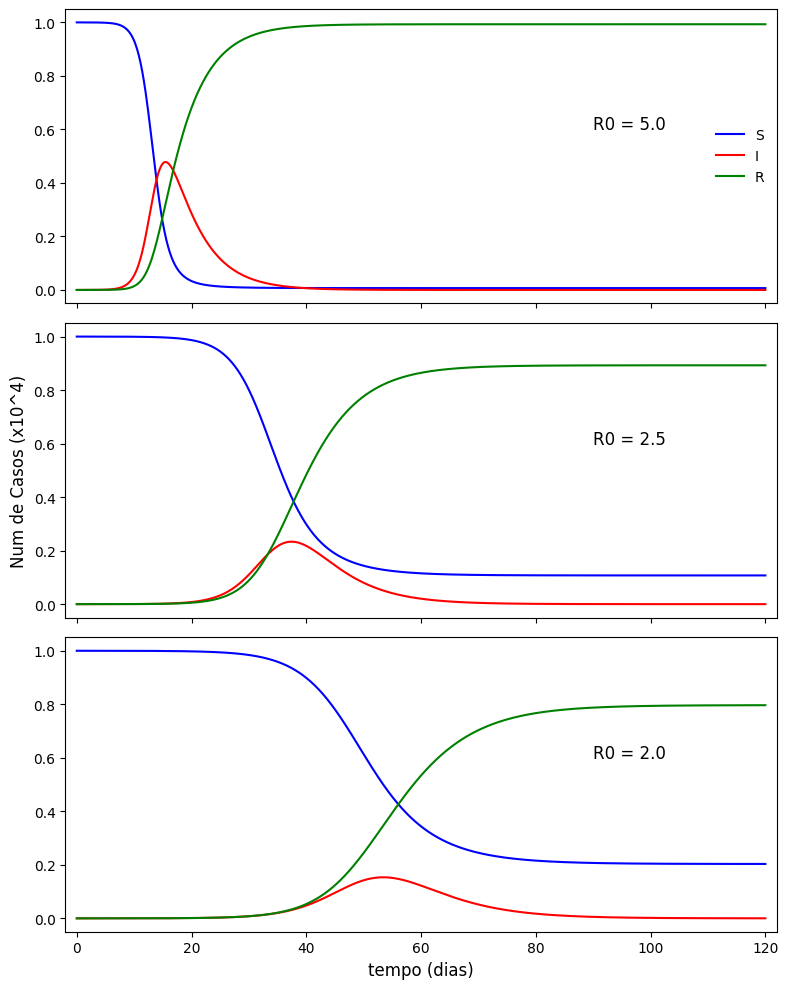

In [ ]:
valores_R_zero = [5.0, 2.5, 2.0]

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

for i, Rz in enumerate(valores_R_zero):
    beta_temp = (Rz * gamma) / S0

    def equacoes_temp(r, t):
        S, I, R = r
        return np.array([-beta_temp * S * I,
                         beta_temp * S * I - gamma * I,
                         gamma * I])

    t_temp, res_temp = rk4_sistema(equacoes_temp, ti, tf, N_passos, condicao_inicial)
    S_temp, I_temp, R_temp = res_temp

    axs[i].plot(t_temp, S_temp / N_pop, color='blue', label='S')
    axs[i].plot(t_temp, I_temp / N_pop, color='red', label='I')
    axs[i].plot(t_temp, R_temp / N_pop, color='green', label='R')

    axs[i].text(90, 0.6, f'R0 = {Rz}', fontsize=12)
    axs[i].set_ylim(-0.05, 1.05)
    axs[i].set_xlim(-2, 122)

    if i == 0:
        axs[i].legend(loc='center right', frameon=False)
    if i == 1:
        axs[i].set_ylabel('Num de Casos (x10^4)', fontsize=12)

axs[2].set_xlabel('tempo (dias)', fontsize=12)
plt.tight_layout()
plt.show()

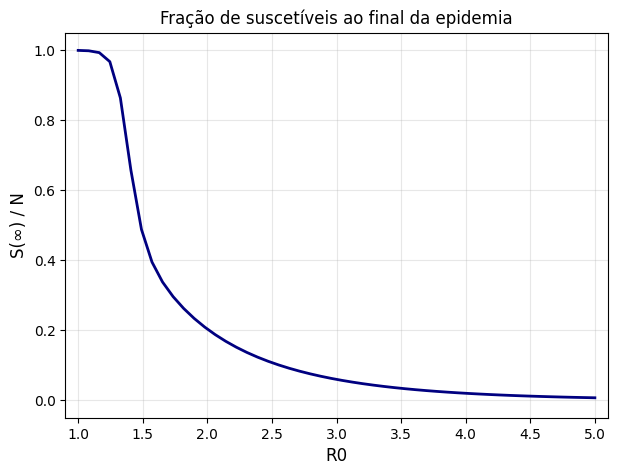

In [ ]:
R0_variados = np.linspace(1, 5, 50)
S_final_fracao = []

for Rz in R0_variados:
    beta_temp = (Rz * gamma) / S0

    def equacoes_temp(r, t):
        S, I, R = r
        return np.array([-beta_temp * S * I,
                         beta_temp * S * I - gamma * I,
                         gamma * I])

    t_temp, res_temp = rk4_sistema(equacoes_temp, ti, tf, N_passos, condicao_inicial)
    S_final = res_temp[0][-1]
    S_final_fracao.append(S_final / N_pop)

plt.figure(figsize=(7, 5))
plt.plot(R0_variados, S_final_fracao, color='navy', linewidth=2)
plt.xlabel('R0', fontsize=12)
plt.ylabel('S(\u221E) / N', fontsize=12)
plt.xlim(0.9, 5.1)
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.title('Fração de suscetíveis ao final da epidemia')
plt.show()

**Modelo SIR com vacinação**

In [ ]:
nu = 0.01 # taxa de vacinação (dia^-1)
V0 = 0
condicao_inicial_vac = [S0, I0, R0_rec, V0]

def equacoes_SIR_vacina(r, t):
    S, I, R, V = r

    dSdt = -beta * S * I - nu * S
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I
    dVdt = nu * S

    return np.array([dSdt, dIdt, dRdt, dVdt])

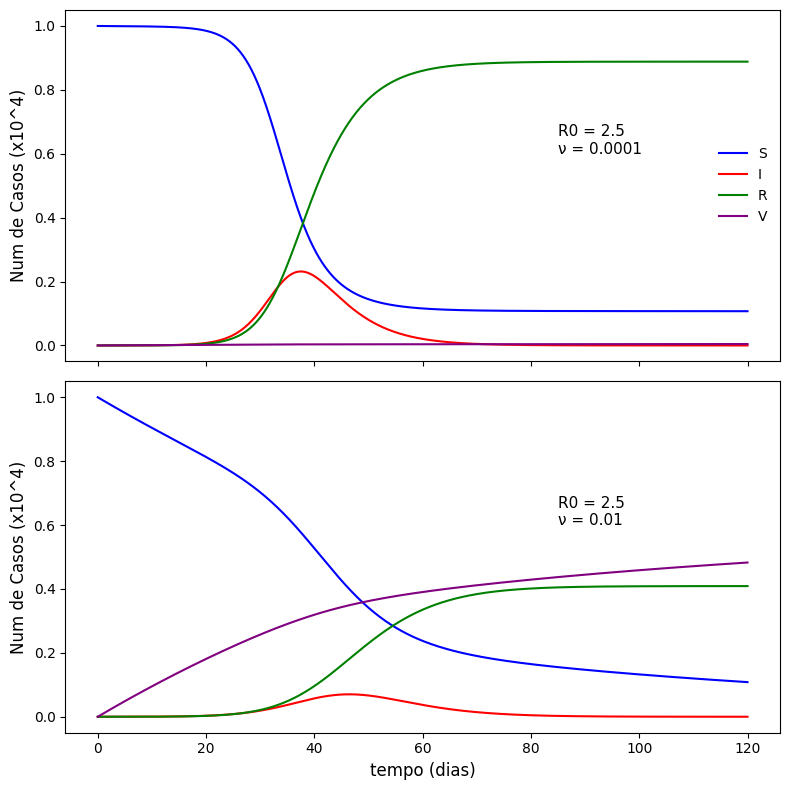

In [ ]:
valores_nu = [0.0001, 0.01]

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for i, nu_val in enumerate(valores_nu):

    def equacoes_vacina_temp(r, t):
        S, I, R, V = r
        return np.array([-beta * S * I - nu_val * S,
                          beta * S * I - gamma * I,
                          gamma * I,
                          nu_val * S])

    t_temp, res_temp = rk4_sistema(equacoes_vacina_temp, ti, tf, N_passos, condicao_inicial_vac)
    S_temp, I_temp, R_temp, V_temp = res_temp

    axs[i].plot(t_temp, S_temp / N_pop, color='blue', label='S')
    axs[i].plot(t_temp, I_temp / N_pop, color='red', label='I')
    axs[i].plot(t_temp, R_temp / N_pop, color='green', label='R')
    axs[i].plot(t_temp, V_temp / N_pop, color='purple', label='V')

    axs[i].text(85, 0.6, f'R0 = {R_zero}\nν = {nu_val}', fontsize=11)
    axs[i].set_ylim(-0.05, 1.05)

    if i == 0:
        axs[i].legend(loc='center right', frameon=False)

axs[1].set_xlabel('tempo (dias)', fontsize=12)
axs[0].set_ylabel('Num de Casos (x10^4)', fontsize=12)
axs[1].set_ylabel('Num de Casos (x10^4)', fontsize=12)
plt.tight_layout()
plt.show()

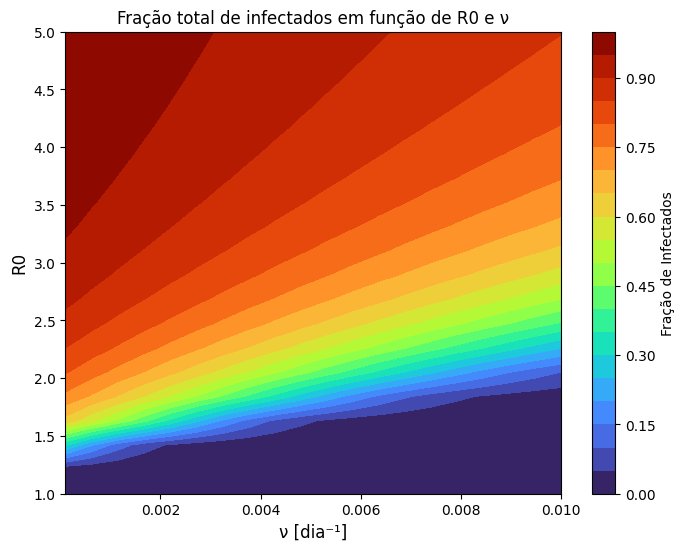

In [ ]:
R0_grid = np.linspace(1.0, 5.0, 20)
nu_grid = np.linspace(0.0001, 0.01, 20)

fracao_infectados = np.zeros((len(R0_grid), len(nu_grid)))

for i, Rz in enumerate(R0_grid):
    beta_temp = (Rz * gamma) / S0

    for j, nu_val in enumerate(nu_grid):

        def eq_temp(r, t):
            S, I, R, V = r
            return np.array([-beta_temp * S * I - nu_val * S,beta_temp * S * I - gamma * I,gamma * I,nu_val * S])

        n,res_temp = rk4_sistema(eq_temp, ti, tf, N_passos, condicao_inicial_vac)
        R_final = res_temp[2][-1]
        fracao_infectados[i, j] = R_final / N_pop  # total que foi infectado ao longo da epidemia

plt.figure(figsize=(8, 6))
cs = plt.contourf(nu_grid, R0_grid, fracao_infectados, levels=20, cmap='turbo')
plt.colorbar(cs, label='Fração de Infectados')
plt.xlabel('ν [dia⁻¹]', fontsize=12)
plt.ylabel('R0', fontsize=12)
plt.title('Fração total de infectados em função de R0 e ν')
plt.show()


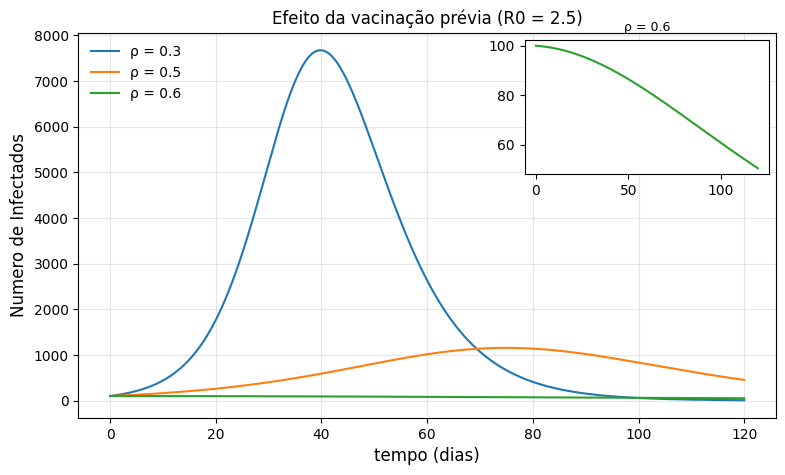

Fração mínima teórica para imunidade de rebanho (R0 = 2.5): ρ = 0.60


In [ ]:
rho_valores = [0.3, 0.5, 0.6]
I0_novo = 100
R0_novo = 0

fig, ax = plt.subplots(figsize=(9, 5))

for rho in rho_valores:
    S0_novo = (1 - rho) * N_pop - I0_novo
    condicao_rho = [S0_novo, I0_novo, R0_novo]

    def eq_rho(r, t):
        S, I, R = r
        return np.array([-beta * S * I,
                          beta * S * I - gamma * I,
                          gamma * I])

    t_rho, res_rho = rk4_sistema(eq_rho, ti, tf, N_passos, condicao_rho)
    ax.plot(t_rho, res_rho[1], label=f'ρ = {rho}')

ax.set_xlabel('tempo (dias)', fontsize=12)
ax.set_ylabel('Numero de Infectados', fontsize=12)
ax.set_title(f'Efeito da vacinação prévia (R0 = {R_zero})')
ax.legend(loc='upper left', frameon=False)
ax.grid(alpha=0.3)


from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = inset_axes(ax, width="35%", height="35%", loc='upper right')
S0_06 = (1 - 0.6) * N_pop - I0_novo
t_06, res_06 = rk4_sistema(eq_rho, ti, tf, N_passos, [S0_06, I0_novo, R0_novo])
axins.plot(t_06, res_06[1], color='C2')
axins.set_title('ρ = 0.6', fontsize=9)


plt.show()

rho_min = 1 - 1 / R_zero
print(f'Fração mínima teórica para imunidade de rebanho (R0 = {R_zero}): ρ = {rho_min:.2f}')